In [12]:
import sys
print(sys.executable)
print(sys.version)

/packages/apps/jupyter/2025-03-24/bin/python3.12
3.12.9 | packaged by conda-forge | (main, Mar  4 2025, 22:48:41) [GCC 13.3.0]


In [3]:
import sys
!{sys.executable} -m pip install --user scikit-learn

     |████████████████████████████████| 22.2 MB 24.8 MB/s            
     |████████████████████████████████| 25.9 MB 125.3 MB/s            
     |████████████████████████████████| 309 kB 124.1 MB/s            


In [6]:
import sys
!{sys.executable} -m pip install --user xgboost

     |████████████████████████████████| 173.6 MB 10 kB/s               


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

In [2]:
import sklearn
print(sklearn.__version__)

1.7.2


In [2]:
LOOKBACK = 180
HORIZON = 30   # change to 1, 7, or 30
CUTOFF = pd.Timestamp("2016-01-01")

SAVE_DIR = f"xgboost_sirikit_{HORIZON}day"
os.makedirs(SAVE_DIR, exist_ok=True)

np.random.seed(42)

In [3]:
CSV_PATH = r"MSEA-Res_database_v2/Dynamic_components/Level2/Level2_5140_1974_Sirikit.csv"

df = pd.read_csv(CSV_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").dropna(subset=["Storage_km3"]).reset_index(drop=True)

print("Data shape:", df.shape)
print(df.head())
print(df.tail())

Data shape: (13169, 2)
        Date  Storage_km3
0 1987-12-12     4.064504
1 1987-12-13     4.065823
2 1987-12-14     4.067143
3 1987-12-15     4.068463
4 1987-12-16     4.069783
            Date  Storage_km3
13164 2023-12-27     5.316066
13165 2023-12-28     5.314915
13166 2023-12-29     5.313879
13167 2023-12-30     5.312958
13168 2023-12-31     5.312153


In [4]:
train_df = df[df["Date"] < CUTOFF].copy()
test_df  = df[df["Date"] >= CUTOFF].copy()

print("Train:", train_df["Date"].min(), "→", train_df["Date"].max(), "n =", len(train_df))
print("Test :", test_df["Date"].min(), "→", test_df["Date"].max(), "n =", len(test_df))

Train: 1987-12-12 00:00:00 → 2015-12-31 00:00:00 n = 10247
Test : 2016-01-01 00:00:00 → 2023-12-31 00:00:00 n = 2922


In [5]:
x_scaler = StandardScaler().fit(train_df[["Storage_km3"]])
y_scaler = x_scaler   # for univariate case, input and target are same variable

train_s = x_scaler.transform(train_df[["Storage_km3"]]).astype(np.float32)
test_s  = x_scaler.transform(test_df[["Storage_km3"]]).astype(np.float32)

print("train_s:", train_s.shape)
print("test_s :", test_s.shape)

train_s: (10247, 1)
test_s : (2922, 1)


In [6]:
def make_windows_multistep(series_2d, target_1d, lookback=180, horizon=30, stride=1):
    """
    series_2d: [T, num_features]
    target_1d: [T]
    
    returns:
        X: [N, lookback, num_features]
        y: [N, horizon]
    """
    X, y = [], []

    for i in range(0, len(series_2d) - lookback - horizon + 1, stride):
        X.append(series_2d[i:i+lookback, :])
        y.append(target_1d[i+lookback:i+lookback+horizon])

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    if horizon == 1:
        y = y.reshape(-1, 1)

    return X, y

In [7]:
X_train, y_train = make_windows_multistep(
    train_s,
    train_s[:, 0],
    lookback=LOOKBACK,
    horizon=HORIZON
)

X_test, y_test = make_windows_multistep(
    test_s,
    test_s[:, 0],
    lookback=LOOKBACK,
    horizon=HORIZON
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (10038, 180, 1)
y_train: (10038, 30)
X_test : (2713, 180, 1)
y_test : (2713, 30)


In [8]:
N_train, T, F = X_train.shape
N_test = X_test.shape[0]

X_train_xgb = X_train.reshape(N_train, T * F)
X_test_xgb  = X_test.reshape(N_test, T * F)

print("X_train_xgb:", X_train_xgb.shape)
print("X_test_xgb :", X_test_xgb.shape)

X_train_xgb: (10038, 180)
X_test_xgb : (2713, 180)


In [9]:
VAL_FRAC = 0.15

n_val = int(len(X_train_xgb) * VAL_FRAC)

X_tr = X_train_xgb[:-n_val]
y_tr = y_train[:-n_val]

X_val = X_train_xgb[-n_val:]
y_val = y_train[-n_val:]

print("X_tr :", X_tr.shape, y_tr.shape)
print("X_val:", X_val.shape, y_val.shape)

X_tr : (8533, 180) (8533, 30)
X_val: (1505, 180) (1505, 30)


In [14]:
models = []
val_rmse_per_step = []

for h in range(HORIZON):
    print(f"\nTraining XGBoost for forecast step {h+1}/{HORIZON}")

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1200,
        learning_rate=0.02,
        max_depth=3,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=0,
        tree_method="hist",
        n_jobs=-1
    )

    model.fit(
        X_tr,
        y_tr[:, h],
        eval_set=[(X_val, y_val[:, h])],
        verbose=False
    )

    val_pred_h = model.predict(X_val)
    val_rmse_h = np.sqrt(mean_squared_error(y_val[:, h], val_pred_h))

    print(f"Validation RMSE scaled, step {h+1}: {val_rmse_h:.6f}")

    models.append(model)
    val_rmse_per_step.append(val_rmse_h)

print("\nDone training all XGBoost horizon models.")


Training XGBoost for forecast step 1/30
Validation RMSE scaled, step 1: 0.020698

Training XGBoost for forecast step 2/30
Validation RMSE scaled, step 2: 0.035917

Training XGBoost for forecast step 3/30
Validation RMSE scaled, step 3: 0.052630

Training XGBoost for forecast step 4/30
Validation RMSE scaled, step 4: 0.070650

Training XGBoost for forecast step 5/30
Validation RMSE scaled, step 5: 0.088706

Training XGBoost for forecast step 6/30
Validation RMSE scaled, step 6: 0.108723

Training XGBoost for forecast step 7/30
Validation RMSE scaled, step 7: 0.128203

Training XGBoost for forecast step 8/30
Validation RMSE scaled, step 8: 0.147990

Training XGBoost for forecast step 9/30
Validation RMSE scaled, step 9: 0.169376

Training XGBoost for forecast step 10/30
Validation RMSE scaled, step 10: 0.188685

Training XGBoost for forecast step 11/30
Validation RMSE scaled, step 11: 0.209730

Training XGBoost for forecast step 12/30
Validation RMSE scaled, step 12: 0.228563

Training 

In [15]:
import joblib
import os

MODEL_DIR = f"{SAVE_DIR}/models"
os.makedirs(MODEL_DIR, exist_ok=True)

for h, model in enumerate(models):
    joblib.dump(model, f"{MODEL_DIR}/xgboost_{HORIZON}day_step_{h+1:02d}.joblib")

print(f"Saved {len(models)} XGBoost models to:", MODEL_DIR)

Saved 30 XGBoost models to: xgboost_sirikit_30day/models


In [16]:
y_pred_s = np.zeros_like(y_test, dtype=np.float32)

for h, model in enumerate(models):
    y_pred_s[:, h] = model.predict(X_test_xgb)

print("y_pred_s:", y_pred_s.shape)
print("y_test   :", y_test.shape)

y_pred_s: (2713, 30)
y_test   : (2713, 30)


In [17]:
y_pred = y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).reshape(-1, HORIZON)
y_true = y_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1, HORIZON)

print("y_pred:", y_pred.shape)
print("y_true:", y_true.shape)

y_pred: (2713, 30)
y_true: (2713, 30)


In [18]:
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae = np.mean(np.abs(y_true - y_pred))
r2 = r2_score(y_true.reshape(-1), y_pred.reshape(-1))

print(f"\n[XGBoost Test Forecast | Horizon={HORIZON}]")
print(f"RMSE = {rmse:.6f} km³")
print(f"MAE  = {mae:.6f} km³")
print(f"R²   = {r2:.6f}")


[XGBoost Test Forecast | Horizon=30]
RMSE = 0.409329 km³
MAE  = 0.273896 km³
R²   = 0.885439


In [19]:
rows = []

print("\nPer-step test metrics:")
for h in range(HORIZON):
    rmse_h = np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
    mae_h = mean_absolute_error(y_true[:, h], y_pred[:, h])
    r2_h = r2_score(y_true[:, h], y_pred[:, h])

    rows.append({
        "Model": "XGBoost",
        "Horizon": HORIZON,
        "Step": h + 1,
        "RMSE_km3": rmse_h,
        "MAE_km3": mae_h,
        "R2": r2_h
    })

    print(f"Day {h+1:02d}: RMSE={rmse_h:.6f} | MAE={mae_h:.6f} | R²={r2_h:.6f}")

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(f"{SAVE_DIR}/xgboost_{HORIZON}day_per_step_metrics.csv", index=False)

metrics_df.head()


Per-step test metrics:
Day 01: RMSE=0.034434 | MAE=0.023168 | R²=0.999198
Day 02: RMSE=0.056632 | MAE=0.039993 | R²=0.997830
Day 03: RMSE=0.080942 | MAE=0.057813 | R²=0.995563
Day 04: RMSE=0.106754 | MAE=0.077402 | R²=0.992277
Day 05: RMSE=0.131982 | MAE=0.095311 | R²=0.988186
Day 06: RMSE=0.157794 | MAE=0.114401 | R²=0.983100
Day 07: RMSE=0.183797 | MAE=0.134053 | R²=0.977054
Day 08: RMSE=0.208607 | MAE=0.151848 | R²=0.970419
Day 09: RMSE=0.234787 | MAE=0.171410 | R²=0.962500
Day 10: RMSE=0.258969 | MAE=0.189946 | R²=0.954343
Day 11: RMSE=0.283255 | MAE=0.207969 | R²=0.945336
Day 12: RMSE=0.308367 | MAE=0.227233 | R²=0.935165
Day 13: RMSE=0.332269 | MAE=0.245100 | R²=0.924667
Day 14: RMSE=0.354854 | MAE=0.262488 | R²=0.914011
Day 15: RMSE=0.377707 | MAE=0.280612 | R²=0.902502
Day 16: RMSE=0.396964 | MAE=0.293925 | R²=0.892223
Day 17: RMSE=0.419884 | MAE=0.309438 | R²=0.879322
Day 18: RMSE=0.440461 | MAE=0.328054 | R²=0.867097
Day 19: RMSE=0.459381 | MAE=0.339614 | R²=0.855318
Day 20:

,Model,Horizon,Step,RMSE_km3,MAE_km3,R2
0,XGBoost,30,1,0.034434,0.023168,0.999198
1,XGBoost,30,2,0.056632,0.039993,0.997830
2,XGBoost,30,3,0.080942,0.057813,0.995563
3,XGBoost,30,4,0.106754,0.077402,0.992277
4,XGBoost,30,5,0.131982,0.095311,0.988186


In [20]:
np.save(f"{SAVE_DIR}/xgboost_{HORIZON}day_y_true.npy", y_true)
np.save(f"{SAVE_DIR}/xgboost_{HORIZON}day_y_pred.npy", y_pred)

summary = pd.DataFrame([{
    "Model": "XGBoost",
    "Horizon": HORIZON,
    "Overall_RMSE_km3": rmse,
    "Overall_MAE_km3": mae,
    "Overall_R2": r2
}])

summary.to_csv(f"{SAVE_DIR}/xgboost_{HORIZON}day_summary_metrics.csv", index=False)

summary

,Model,Horizon,Overall_RMSE_km3,Overall_MAE_km3,Overall_R2
0,XGBoost,30,0.409329,0.273896,0.885439


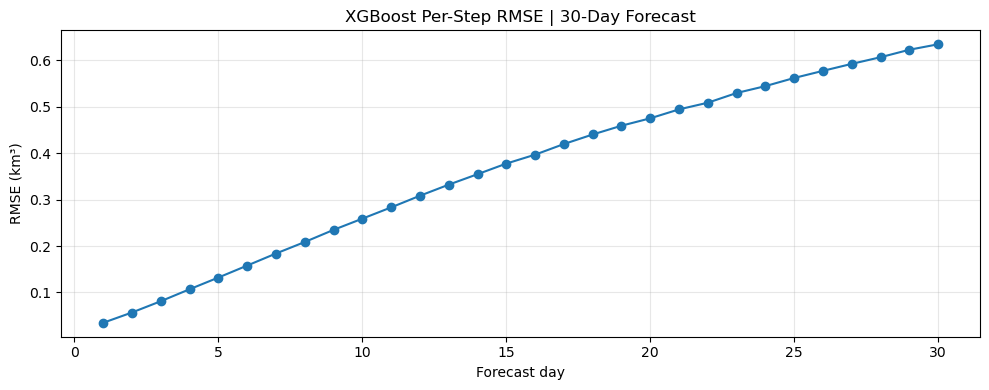

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(metrics_df["Step"], metrics_df["RMSE_km3"], marker="o")
plt.xlabel("Forecast day")
plt.ylabel("RMSE (km³)")
plt.title(f"XGBoost Per-Step RMSE | {HORIZON}-Day Forecast")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/xgboost_{HORIZON}day_per_step_rmse.png", dpi=300)
plt.show()

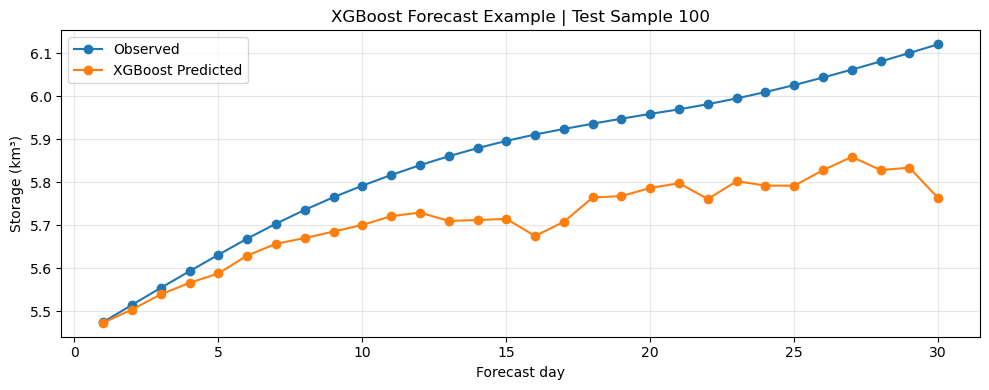

In [22]:
sample_idx = 100  # change this

plt.figure(figsize=(10, 4))
plt.plot(range(1, HORIZON + 1), y_true[sample_idx], marker="o", label="Observed")
plt.plot(range(1, HORIZON + 1), y_pred[sample_idx], marker="o", label="XGBoost Predicted")
plt.xlabel("Forecast day")
plt.ylabel("Storage (km³)")
plt.title(f"XGBoost Forecast Example | Test Sample {sample_idx}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/xgboost_{HORIZON}day_sample_forecast.png", dpi=300)
plt.show()

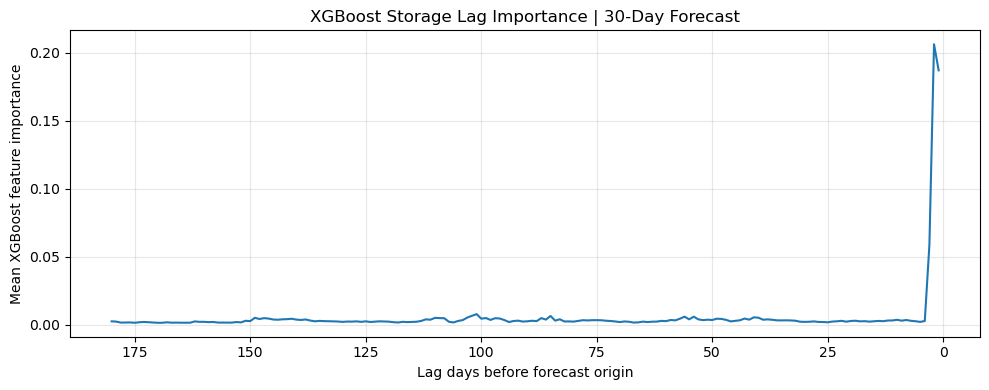

In [23]:
# Average feature importance across all horizon-specific models
importances = np.zeros(X_train_xgb.shape[1])

for model in models:
    importances += model.feature_importances_

importances /= len(models)

# reshape back to [lookback, features]
importance_by_lag = importances.reshape(LOOKBACK, F)

# For univariate, feature 0 = storage
storage_importance = importance_by_lag[:, 0]

# Convert index to lag days
# index 0 = oldest day, index 179 = most recent day
lags = np.arange(LOOKBACK, 0, -1)

plt.figure(figsize=(10, 4))
plt.plot(lags, storage_importance)
plt.xlabel("Lag days before forecast origin")
plt.ylabel("Mean XGBoost feature importance")
plt.title(f"XGBoost Storage Lag Importance | {HORIZON}-Day Forecast")
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/xgboost_{HORIZON}day_lag_importance.png", dpi=300)
plt.show()

In [24]:
xgb_result_row = {
    "Model": "XGBoost",
    "Input": "Storage",
    "Lookback": LOOKBACK,
    "Horizon": HORIZON,
    "RMSE_km3": rmse,
    "MAE_km3": mae,
    "R2": r2
}

xgb_result_df = pd.DataFrame([xgb_result_row])
xgb_result_df

,Model,Input,Lookback,Horizon,RMSE_km3,MAE_km3,R2
0,XGBoost,Storage,180,30,0.409329,0.273896,0.885439


In [27]:
xgb_result_df.to_csv(f"{SAVE_DIR}/xgboost_{HORIZON}day_final_result_row.csv", index=False)

In [25]:
X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_test_rf  = X_test.reshape(X_test.shape[0], -1)

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import joblib
import os

models_rf = []
val_rmse_per_step_rf = []

MODEL_DIR = f"{SAVE_DIR}/random_forest_models"
os.makedirs(MODEL_DIR, exist_ok=True)

for h in range(HORIZON):
    print(f"\nTraining Random Forest for forecast step {h+1}/{HORIZON}")

    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=0,
        n_jobs=-1
    )

    rf.fit(X_tr, y_tr[:, h])

    val_pred_h = rf.predict(X_val)
    val_rmse_h = np.sqrt(mean_squared_error(y_val[:, h], val_pred_h))

    print(f"Validation RMSE scaled, step {h+1}: {val_rmse_h:.6f}")

    models_rf.append(rf)
    val_rmse_per_step_rf.append(val_rmse_h)

    joblib.dump(rf, f"{MODEL_DIR}/rf_{HORIZON}day_step_{h+1:02d}.joblib")

print("\nDone training and saving all Random Forest horizon models.")


Training Random Forest for forecast step 1/30
Validation RMSE scaled, step 1: 0.087238

Training Random Forest for forecast step 2/30
Validation RMSE scaled, step 2: 0.105598

Training Random Forest for forecast step 3/30
Validation RMSE scaled, step 3: 0.124490

Training Random Forest for forecast step 4/30
Validation RMSE scaled, step 4: 0.147068

Training Random Forest for forecast step 5/30
Validation RMSE scaled, step 5: 0.168337

Training Random Forest for forecast step 6/30
Validation RMSE scaled, step 6: 0.188747

Training Random Forest for forecast step 7/30
Validation RMSE scaled, step 7: 0.212408

Training Random Forest for forecast step 8/30
Validation RMSE scaled, step 8: 0.233430

Training Random Forest for forecast step 9/30
Validation RMSE scaled, step 9: 0.253963

Training Random Forest for forecast step 10/30
Validation RMSE scaled, step 10: 0.279208

Training Random Forest for forecast step 11/30
Validation RMSE scaled, step 11: 0.304785

Training Random Forest for 

In [29]:
y_pred_s_rf = np.zeros_like(y_test, dtype=np.float32)

for h, rf in enumerate(models_rf):
    y_pred_s_rf[:, h] = rf.predict(X_test_xgb)  # same flattened test input

print("y_pred_s_rf:", y_pred_s_rf.shape)
print("y_test     :", y_test.shape)

y_pred_s_rf: (2713, 30)
y_test     : (2713, 30)


In [30]:
y_pred_rf = y_scaler.inverse_transform(y_pred_s_rf.reshape(-1, 1)).reshape(-1, HORIZON)
y_true_rf = y_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1, HORIZON)

In [31]:
from sklearn.metrics import mean_absolute_error, r2_score

rmse_rf = np.sqrt(np.mean((y_true_rf - y_pred_rf) ** 2))
mae_rf = np.mean(np.abs(y_true_rf - y_pred_rf))
r2_rf = r2_score(y_true_rf.reshape(-1), y_pred_rf.reshape(-1))

print(f"\n[Random Forest Test Forecast | Horizon={HORIZON}]")
print(f"RMSE = {rmse_rf:.6f} km³")
print(f"MAE  = {mae_rf:.6f} km³")
print(f"R²   = {r2_rf:.6f}")


[Random Forest Test Forecast | Horizon=30]
RMSE = 0.468828 km³
MAE  = 0.329655 km³
R²   = 0.849713


In [32]:
rf_result_df = pd.DataFrame([{
    "Model": "Random Forest",
    "Input": "Storage",
    "Lookback": LOOKBACK,
    "Horizon": HORIZON,
    "RMSE_km3": rmse_rf,
    "MAE_km3": mae_rf,
    "R2": r2_rf
}])

rf_result_df.to_csv(f"{SAVE_DIR}/random_forest_{HORIZON}day_final_result_row.csv", index=False)
rf_result_df

,Model,Input,Lookback,Horizon,RMSE_km3,MAE_km3,R2
0,Random Forest,Storage,180,30,0.468828,0.329655,0.849713


In [33]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(LOOKBACK, HORIZON)

(10038, 180, 1) (10038, 30)
(2713, 180, 1) (2713, 30)
180 30


In [36]:
### gru
import sys
!{sys.executable} -m pip install --user torch

     |███████████████████████████████▏| 860.3 MB 6.7 MB/s eta 0:00:04  

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



     |████████████████████████████████| 881.9 MB 14 kB/s               


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [35]:
HORIZON = 30
LOOKBACK = 180

SAVE_DIR = f"gru_sirikit_{HORIZON}day"
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [36]:
VAL_FRAC = 0.15

n_val = int(len(X_train) * VAL_FRAC)

X_tr = X_train[:-n_val]
y_tr = y_train[:-n_val]

X_val = X_train[-n_val:]
y_val = y_train[-n_val:]

print("X_tr :", X_tr.shape, y_tr.shape)
print("X_val:", X_val.shape, y_val.shape)
print("X_test:", X_test.shape, y_test.shape)

X_tr : (8533, 180, 1) (8533, 30)
X_val: (1505, 180, 1) (1505, 30)
X_test: (2713, 180, 1) (2713, 30)


In [37]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

        if self.y.ndim == 1:
            self.y = self.y.reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


batch_size = 128

train_loader = DataLoader(
    SeqDataset(X_tr, y_tr),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    SeqDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    SeqDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False
)

In [38]:
class GRUForecaster(nn.Module):
    def __init__(
        self,
        input_dim=1,
        hidden_dim=128,
        num_layers=2,
        dropout=0.3,
        out_dim=30
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False
        )

        self.head = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, return_hidden=False):
        out, h = self.gru(x)          # out: [B, T, hidden_dim]
        h_last = out[:, -1, :]       # [B, hidden_dim]
        yhat = self.head(h_last)     # [B, horizon]

        if return_hidden:
            return yhat, out

        return yhat

In [39]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    loss_fn = nn.MSELoss()

    total_loss = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)

        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(xb)
        n += len(xb)

    return total_loss / n


@torch.no_grad()
def evaluate_scaled(model, loader, device):
    model.eval()

    preds = []
    trues = []

    for xb, yb in loader:
        xb = xb.to(device)

        pred = model(xb).cpu().numpy()

        preds.append(pred)
        trues.append(yb.numpy())

    preds = np.vstack(preds)
    trues = np.vstack(trues)

    rmse = np.sqrt(np.mean((trues - preds) ** 2))
    mae = np.mean(np.abs(trues - preds))

    return rmse, mae

In [40]:
input_dim = X_train.shape[2]

gru = GRUForecaster(
    input_dim=input_dim,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3,
    out_dim=HORIZON
).to(device)

optimizer = torch.optim.AdamW(gru.parameters(), lr=1e-3, weight_decay=1e-5)

best_val_rmse = float("inf")
best_state = None

patience = 20
bad = 0
max_epochs = 300

history = []

for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(gru, train_loader, optimizer, device)
    val_rmse, val_mae = evaluate_scaled(gru, val_loader, device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_rmse_scaled": val_rmse,
        "val_mae_scaled": val_mae
    })

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train loss={train_loss:.6f} | "
            f"val RMSE={val_rmse:.6f} | "
            f"val MAE={val_mae:.6f}"
        )

    if val_rmse < best_val_rmse - 1e-6:
        best_val_rmse = val_rmse
        bad = 0
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in gru.state_dict().items()
        }

        torch.save({
            "model_state": best_state,
            "config": {
                "model": "GRU",
                "input_dim": input_dim,
                "hidden_dim": 128,
                "num_layers": 2,
                "dropout": 0.3,
                "out_dim": HORIZON,
                "lookback": LOOKBACK
            },
            "best_val_rmse_scaled": best_val_rmse
        }, f"{SAVE_DIR}/gru_{HORIZON}day_best.pt")

    else:
        bad += 1

    if bad >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

gru.load_state_dict({k: v.to(device) for k, v in best_state.items()})
gru.eval()

print("Best validation RMSE scaled:", best_val_rmse)

Epoch 001 | train loss=0.284580 | val RMSE=0.316495 | val MAE=0.194024
Epoch 010 | train loss=0.074075 | val RMSE=0.243057 | val MAE=0.152206
Epoch 020 | train loss=0.047711 | val RMSE=0.244035 | val MAE=0.158983
Epoch 030 | train loss=0.035420 | val RMSE=0.293722 | val MAE=0.193123
Early stopping at epoch 39
Best validation RMSE scaled: 0.2255503


In [41]:
@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()

    preds = []
    trues = []

    for xb, yb in loader:
        xb = xb.to(device)

        pred = model(xb).cpu().numpy()

        preds.append(pred)
        trues.append(yb.numpy())

    preds = np.vstack(preds)
    trues = np.vstack(trues)

    return preds, trues


y_pred_s, y_true_s = predict_model(gru, test_loader, device)

print("y_pred_s:", y_pred_s.shape)
print("y_true_s:", y_true_s.shape)

y_pred_s: (2713, 30)
y_true_s: (2713, 30)


In [42]:
y_pred = y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).reshape(-1, HORIZON)
y_true = y_scaler.inverse_transform(y_true_s.reshape(-1, 1)).reshape(-1, HORIZON)

print("y_pred:", y_pred.shape)
print("y_true:", y_true.shape)

y_pred: (2713, 30)
y_true: (2713, 30)


In [43]:
print("Available scaler names:")
print("y_scaler" in globals())
print("x_scaler" in globals())
print("scaler" in globals())

Available scaler names:
True
True
False


In [45]:
rmse_gru = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae_gru = np.mean(np.abs(y_true - y_pred))
r2_gru = r2_score(y_true.reshape(-1), y_pred.reshape(-1))

print(f"\n[GRU Test Forecast | Horizon={HORIZON}]")
print(f"RMSE = {rmse_gru:.6f} km³")
print(f"MAE  = {mae_gru:.6f} km³")
print(f"R²   = {r2_gru:.6f}")


[GRU Test Forecast | Horizon=30]
RMSE = 0.388845 km³
MAE  = 0.254612 km³
R²   = 0.896617


In [46]:
rows = []

print("\nPer-step GRU metrics:")

for h in range(HORIZON):
    rmse_h = np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
    mae_h = mean_absolute_error(y_true[:, h], y_pred[:, h])
    r2_h = r2_score(y_true[:, h], y_pred[:, h])

    rows.append({
        "Model": "GRU",
        "Input": "Storage",
        "Lookback": LOOKBACK,
        "Horizon": HORIZON,
        "Step": h + 1,
        "RMSE_km3": rmse_h,
        "MAE_km3": mae_h,
        "R2": r2_h
    })

    print(
        f"Day {h+1:02d}: "
        f"RMSE={rmse_h:.6f} | "
        f"MAE={mae_h:.6f} | "
        f"R²={r2_h:.6f}"
    )

gru_metrics_df = pd.DataFrame(rows)
gru_metrics_df.to_csv(f"{SAVE_DIR}/gru_{HORIZON}day_per_step_metrics.csv", index=False)

gru_metrics_df.head()


Per-step GRU metrics:
Day 01: RMSE=0.075008 | MAE=0.055054 | R²=0.996196
Day 02: RMSE=0.092239 | MAE=0.063179 | R²=0.994243
Day 03: RMSE=0.080903 | MAE=0.059384 | R²=0.995568
Day 04: RMSE=0.100473 | MAE=0.074121 | R²=0.993159
Day 05: RMSE=0.102630 | MAE=0.077174 | R²=0.992856
Day 06: RMSE=0.122357 | MAE=0.084799 | R²=0.989838
Day 07: RMSE=0.148372 | MAE=0.108310 | R²=0.985047
Day 08: RMSE=0.170263 | MAE=0.121418 | R²=0.980294
Day 09: RMSE=0.192255 | MAE=0.139229 | R²=0.974855
Day 10: RMSE=0.212994 | MAE=0.154906 | R²=0.969115
Day 11: RMSE=0.240330 | MAE=0.171970 | R²=0.960649
Day 12: RMSE=0.268673 | MAE=0.191650 | R²=0.950782
Day 13: RMSE=0.301083 | MAE=0.218138 | R²=0.938145
Day 14: RMSE=0.319169 | MAE=0.232489 | R²=0.930436
Day 15: RMSE=0.335610 | MAE=0.243677 | R²=0.923024
Day 16: RMSE=0.381863 | MAE=0.273736 | R²=0.900266
Day 17: RMSE=0.395859 | MAE=0.286843 | R²=0.892737
Day 18: RMSE=0.411310 | MAE=0.300879 | R²=0.884107
Day 19: RMSE=0.438408 | MAE=0.323869 | R²=0.868227
Day 20: 

,Model,Input,Lookback,Horizon,Step,RMSE_km3,MAE_km3,R2
0,GRU,Storage,180,30,1,0.075008,0.055054,0.996196
1,GRU,Storage,180,30,2,0.092239,0.063179,0.994243
2,GRU,Storage,180,30,3,0.080903,0.059384,0.995568
3,GRU,Storage,180,30,4,0.100473,0.074121,0.993159
4,GRU,Storage,180,30,5,0.102630,0.077174,0.992856


In [47]:
gru_result_df = pd.DataFrame([{
    "Model": "GRU",
    "Input": "Storage",
    "Lookback": LOOKBACK,
    "Horizon": HORIZON,
    "RMSE_km3": rmse_gru,
    "MAE_km3": mae_gru,
    "R2": r2_gru
}])

gru_result_df.to_csv(f"{SAVE_DIR}/gru_{HORIZON}day_final_result_row.csv", index=False)

gru_result_df

,Model,Input,Lookback,Horizon,RMSE_km3,MAE_km3,R2
0,GRU,Storage,180,30,0.388845,0.254612,0.896617


In [48]:
np.save(f"{SAVE_DIR}/gru_{HORIZON}day_y_true.npy", y_true)
np.save(f"{SAVE_DIR}/gru_{HORIZON}day_y_pred.npy", y_pred)

history_df = pd.DataFrame(history)
history_df.to_csv(f"{SAVE_DIR}/gru_{HORIZON}day_training_history.csv", index=False)

print("Saved GRU predictions and training history.")

Saved GRU predictions and training history.


In [49]:
SAVE_DIR = f"lstm_sirikit_{HORIZON}day"
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [52]:
class LSTMForecaster(nn.Module):
    def __init__(
        self,
        input_dim=1,
        hidden_dim=128,
        num_layers=2,
        dropout=0.3,
        out_dim=30
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False
        )

        self.head = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, return_hidden=False):
        out, (h, c) = self.lstm(x)   # out: [B, T, hidden_dim]
        h_last = out[:, -1, :]       # [B, hidden_dim]
        yhat = self.head(h_last)     # [B, horizon]

        if return_hidden:
            return yhat, out

        return yhat

In [53]:
input_dim = X_train.shape[2]

lstm = LSTMForecaster(
    input_dim=input_dim,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3,
    out_dim=HORIZON
).to(device)

optimizer = torch.optim.AdamW(lstm.parameters(), lr=1e-3, weight_decay=1e-5)

best_val_rmse = float("inf")
best_state = None

patience = 20
bad = 0
max_epochs = 300

history = []

for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(lstm, train_loader, optimizer, device)
    val_rmse, val_mae = evaluate_scaled(lstm, val_loader, device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_rmse_scaled": val_rmse,
        "val_mae_scaled": val_mae
    })

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train loss={train_loss:.6f} | "
            f"val RMSE={val_rmse:.6f} | "
            f"val MAE={val_mae:.6f}"
        )

    if val_rmse < best_val_rmse - 1e-6:
        best_val_rmse = val_rmse
        bad = 0
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in lstm.state_dict().items()
        }

        torch.save({
            "model_state": best_state,
            "config": {
                "model": "LSTM",
                "input_dim": input_dim,
                "hidden_dim": 128,
                "num_layers": 2,
                "dropout": 0.3,
                "out_dim": HORIZON,
                "lookback": LOOKBACK
            },
            "best_val_rmse_scaled": best_val_rmse
        }, f"{SAVE_DIR}/lstm_{HORIZON}day_best.pt")

    else:
        bad += 1

    if bad >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

lstm.load_state_dict({k: v.to(device) for k, v in best_state.items()})
lstm.eval()

print("Best validation RMSE scaled:", best_val_rmse)

Epoch 001 | train loss=0.361319 | val RMSE=0.325096 | val MAE=0.209172
Epoch 010 | train loss=0.084070 | val RMSE=0.260607 | val MAE=0.165349
Epoch 020 | train loss=0.069824 | val RMSE=0.257495 | val MAE=0.159545
Epoch 030 | train loss=0.042254 | val RMSE=0.257872 | val MAE=0.156495
Epoch 040 | train loss=0.031549 | val RMSE=0.286125 | val MAE=0.166101
Early stopping at epoch 43
Best validation RMSE scaled: 0.22052297


In [54]:
y_pred_s, y_true_s = predict_model(lstm, test_loader, device)

print("y_pred_s:", y_pred_s.shape)
print("y_true_s:", y_true_s.shape)

y_pred_s: (2713, 30)
y_true_s: (2713, 30)


In [55]:
scaler = y_scaler   # use this if your notebook has y_scaler

y_pred = scaler.inverse_transform(y_pred_s.reshape(-1, 1)).reshape(-1, HORIZON)
y_true = scaler.inverse_transform(y_true_s.reshape(-1, 1)).reshape(-1, HORIZON)

print("y_pred:", y_pred.shape)
print("y_true:", y_true.shape)

y_pred: (2713, 30)
y_true: (2713, 30)


In [56]:
rmse_lstm = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae_lstm = np.mean(np.abs(y_true - y_pred))
r2_lstm = r2_score(y_true.reshape(-1), y_pred.reshape(-1))

print(f"\n[LSTM Test Forecast | Horizon={HORIZON}]")
print(f"RMSE = {rmse_lstm:.6f} km³")
print(f"MAE  = {mae_lstm:.6f} km³")
print(f"R²   = {r2_lstm:.6f}")


[LSTM Test Forecast | Horizon=30]
RMSE = 0.368841 km³
MAE  = 0.229098 km³
R²   = 0.906981


In [57]:
rows = []

print("\nPer-step LSTM metrics:")

for h in range(HORIZON):
    rmse_h = np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
    mae_h = mean_absolute_error(y_true[:, h], y_pred[:, h])
    r2_h = r2_score(y_true[:, h], y_pred[:, h])

    rows.append({
        "Model": "LSTM",
        "Input": "Storage",
        "Lookback": LOOKBACK,
        "Horizon": HORIZON,
        "Step": h + 1,
        "RMSE_km3": rmse_h,
        "MAE_km3": mae_h,
        "R2": r2_h
    })

    print(
        f"Day {h+1:02d}: "
        f"RMSE={rmse_h:.6f} | "
        f"MAE={mae_h:.6f} | "
        f"R²={r2_h:.6f}"
    )

lstm_metrics_df = pd.DataFrame(rows)
lstm_metrics_df.to_csv(f"{SAVE_DIR}/lstm_{HORIZON}day_per_step_metrics.csv", index=False)

lstm_metrics_df.head()


Per-step LSTM metrics:
Day 01: RMSE=0.111402 | MAE=0.084232 | R²=0.991609
Day 02: RMSE=0.092411 | MAE=0.071059 | R²=0.994222
Day 03: RMSE=0.088456 | MAE=0.064242 | R²=0.994701
Day 04: RMSE=0.094034 | MAE=0.064743 | R²=0.994007
Day 05: RMSE=0.113249 | MAE=0.081169 | R²=0.991302
Day 06: RMSE=0.117162 | MAE=0.082529 | R²=0.990683
Day 07: RMSE=0.129968 | MAE=0.089785 | R²=0.988526
Day 08: RMSE=0.153641 | MAE=0.104947 | R²=0.983954
Day 09: RMSE=0.176556 | MAE=0.122450 | R²=0.978794
Day 10: RMSE=0.195767 | MAE=0.134726 | R²=0.973909
Day 11: RMSE=0.229595 | MAE=0.156523 | R²=0.964086
Day 12: RMSE=0.253983 | MAE=0.172430 | R²=0.956017
Day 13: RMSE=0.272807 | MAE=0.187372 | R²=0.949217
Day 14: RMSE=0.299978 | MAE=0.207371 | R²=0.938550
Day 15: RMSE=0.324798 | MAE=0.222035 | R²=0.927904
Day 16: RMSE=0.353420 | MAE=0.243631 | R²=0.914570
Day 17: RMSE=0.374714 | MAE=0.258451 | R²=0.903890
Day 18: RMSE=0.391076 | MAE=0.271646 | R²=0.895229
Day 19: RMSE=0.407113 | MAE=0.284030 | R²=0.886368
Day 20:

,Model,Input,Lookback,Horizon,Step,RMSE_km3,MAE_km3,R2
0,LSTM,Storage,180,30,1,0.111402,0.084232,0.991609
1,LSTM,Storage,180,30,2,0.092411,0.071059,0.994222
2,LSTM,Storage,180,30,3,0.088456,0.064242,0.994701
3,LSTM,Storage,180,30,4,0.094034,0.064743,0.994007
4,LSTM,Storage,180,30,5,0.113249,0.081169,0.991302


In [31]:
import os
import numpy as np
import torch
import torch.nn as nn

device = torch.device("cpu")
print("Using device:", device)

SAVE_DIR = "sirikit/30_sirikit"
HORIZON = 30
LOOKBACK = 180

Using device: cpu


In [32]:
class BiLSTMBase(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128, num_layers=1, out_dim=30):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.head = nn.Linear(hidden_dim * 2, out_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        return self.head(h_last)


class BiLSTMTopoAug(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128, num_layers=1, topo_dim=3, out_dim=1):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2 + topo_dim, 128),
            nn.ReLU(),
            nn.Linear(128, out_dim)
        )

    def forward(self, x, phi):
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        z = torch.cat([h_last, phi], dim=1)
        return self.head(z)

In [33]:
base_ckpt_path = f"{SAVE_DIR}/30_day_bilstm_base_best_sirikit.pt"

ckpt_b = torch.load(
    base_ckpt_path,
    map_location=device,
    weights_only=False
)

base_best = BiLSTMBase(
    input_dim=ckpt_b["config"]["input_dim"],
    hidden_dim=ckpt_b["config"]["hidden_dim"],
    out_dim=ckpt_b["config"]["out_dim"]
).to(device)

base_best.load_state_dict(ckpt_b["model_state"])
base_best.eval()

print("Loaded base_best")
print("Baseline checkpoint RMSE:", ckpt_b["rmse"])

Loaded base_best
Baseline checkpoint RMSE: 0.29513985


In [35]:
aug_ckpt_path = f"{SAVE_DIR}/30_day_bilstm_topo_aug_best_sirikit.pt"

ckpt_a = torch.load(
    aug_ckpt_path,
    map_location=device,
    weights_only=False
)

aug_best = BiLSTMTopoAug(
    input_dim=ckpt_a["config"]["input_dim"],
    hidden_dim=ckpt_a["config"]["hidden_dim"],
    topo_dim=ckpt_a["config"]["topo_dim"],
    out_dim=ckpt_a["config"]["out_dim"]
).to(device)

aug_best.load_state_dict(ckpt_a["model_state"])
aug_best.eval()

print("Loaded aug_best")
print("Topo-aug checkpoint RMSE:", ckpt_a["rmse"])

Loaded aug_best
Topo-aug checkpoint RMSE: 0.26311862


In [36]:
mu = ckpt_a["zigzag_norm"]["mu"]
sd = ckpt_a["zigzag_norm"]["sd"]
keep = ckpt_a["zigzag_norm"]["keep_mask"]

phi_test_raw = np.load(f"{SAVE_DIR}/30_day_zigzag_test_per_sample.npy").astype(np.float32)

phi_test_k = phi_test_raw[:, keep]
phi_test_n = (phi_test_k - mu) / (sd + 1e-8)

print("Loaded and normalized phi_test_n")
print("keep mask:", keep)
print("phi_test_n shape:", phi_test_n.shape)

Loaded and normalized phi_test_n
keep mask: [ True False  True  True]
phi_test_n shape: (2713, 3)


In [70]:
print("base_best exists:", "base_best" in globals())
print("aug_best exists :", "aug_best" in globals())
print("phi_test_n exists:", "phi_test_n" in globals())

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("phi_test_n:", phi_test_n.shape)

base_best exists: True
aug_best exists : True
phi_test_n exists: True
X_test: (2713, 180, 1)
y_test: (2713, 30)
phi_test_n: (2713, 3)


In [37]:
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
import torch

@torch.no_grad()
def predict_base(model, X_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    preds = []

    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        yhat = model(xb).cpu().numpy()
        preds.append(yhat)

    return np.vstack(preds)


@torch.no_grad()
def predict_aug(model, X_np, phi_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    P = torch.tensor(phi_np, dtype=torch.float32)
    preds = []

    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        pb = P[i:i+batch_size].to(device)
        yhat = model(xb, pb).cpu().numpy()
        preds.append(yhat)

    return np.vstack(preds)

In [38]:
# Predictions in scaled space
pred_b_s = predict_base(base_best, X_test, device)
pred_a_s = predict_aug(aug_best, X_test, phi_test_n, device)

y_true_s = y_test

print("pred_b_s:", pred_b_s.shape)
print("pred_a_s:", pred_a_s.shape)
print("y_true_s:", y_true_s.shape)

pred_b_s: (2713, 30)
pred_a_s: (2713, 30)
y_true_s: (2713, 30)


In [39]:
# Pick correct scaler
try:
    final_scaler = y_scaler
    print("Using y_scaler")
except NameError:
    final_scaler = scaler
    print("Using scaler")

# Inverse transform to km³
pred_b = final_scaler.inverse_transform(pred_b_s.reshape(-1, 1)).reshape(-1, HORIZON)
pred_a = final_scaler.inverse_transform(pred_a_s.reshape(-1, 1)).reshape(-1, HORIZON)
y_true = final_scaler.inverse_transform(y_true_s.reshape(-1, 1)).reshape(-1, HORIZON)

print("pred_b:", pred_b.shape)
print("pred_a:", pred_a.shape)
print("y_true:", y_true.shape)

Using y_scaler
pred_b: (2713, 30)
pred_a: (2713, 30)
y_true: (2713, 30)


In [40]:
# Final metrics in km³
rmse_b = np.sqrt(np.mean((y_true - pred_b) ** 2))
mae_b = np.mean(np.abs(y_true - pred_b))
r2_b = r2_score(y_true.reshape(-1), pred_b.reshape(-1))

rmse_tda = np.sqrt(np.mean((y_true - pred_a) ** 2))
mae_tda = np.mean(np.abs(y_true - pred_a))
r2_tda = r2_score(y_true.reshape(-1), pred_a.reshape(-1))

tda_compare_df = pd.DataFrame([
    {
        "Model": "BiLSTM",
        "Input": "Storage",
        "Lookback": LOOKBACK,
        "Horizon": HORIZON,
        "RMSE_km3": rmse_b,
        "MAE_km3": mae_b,
        "R2": r2_b
    },
    {
        "Model": "BiLSTM + Zigzag TDA",
        "Input": "Storage + Zigzag PH Features",
        "Lookback": LOOKBACK,
        "Horizon": HORIZON,
        "RMSE_km3": rmse_tda,
        "MAE_km3": mae_tda,
        "R2": r2_tda
    }
])

tda_compare_df

,Model,Input,Lookback,Horizon,RMSE_km3,MAE_km3,R2
0,BiLSTM,Storage,180,30,0.351206,0.228914,0.915663
1,BiLSTM + Zigzag TDA,Storage + Zigzag PH Features,180,30,0.313102,0.192160,0.932971


In [41]:
rmse_improvement = (rmse_b - rmse_tda) / rmse_b * 100
mae_improvement = (mae_b - mae_tda) / mae_b * 100

print(f"RMSE improvement from TDA: {rmse_improvement:.2f}%")
print(f"MAE improvement from TDA : {mae_improvement:.2f}%")

RMSE improvement from TDA: 10.85%
MAE improvement from TDA : 16.06%


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

device = torch.device("cpu")
print("Using device:", device)

HORIZON = 30
LOOKBACK = 180

SAVE_DIR = f"tcn_sirikit_{HORIZON}day"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [15]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (10038, 180, 1)
y_train: (10038, 30)
X_test : (2713, 180, 1)
y_test : (2713, 30)


In [16]:
VAL_FRAC = 0.15

n_val = int(len(X_train) * VAL_FRAC)

X_tr = X_train[:-n_val]
y_tr = y_train[:-n_val]

X_val = X_train[-n_val:]
y_val = y_train[-n_val:]

print("X_tr :", X_tr.shape, y_tr.shape)
print("X_val:", X_val.shape, y_val.shape)
print("X_test:", X_test.shape, y_test.shape)

X_tr : (8533, 180, 1) (8533, 30)
X_val: (1505, 180, 1) (1505, 30)
X_test: (2713, 180, 1) (2713, 30)


In [17]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

        if self.y.ndim == 1:
            self.y = self.y.reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


batch_size = 128

train_loader = DataLoader(
    SeqDataset(X_tr, y_tr),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    SeqDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    SeqDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False
)

In [18]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size]


class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.downsample = (
            nn.Conv1d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else None
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.conv1(x)
        out = self.chomp1(out)
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        out = self.chomp2(out)
        out = self.relu2(out)
        out = self.dropout2(out)

        res = x if self.downsample is None else self.downsample(x)

        return self.relu(out + res)

In [20]:
class TCNForecaster(nn.Module):
    def __init__(
        self,
        input_dim=1,
        channels=[64, 64, 128, 128],
        kernel_size=3,
        dropout=0.3,
        out_dim=30
    ):
        super().__init__()

        layers = []
        num_levels = len(channels)

        for i in range(num_levels):
            dilation = 2 ** i
            in_ch = input_dim if i == 0 else channels[i - 1]
            out_ch = channels[i]

            layers.append(
                TemporalBlock(
                    in_channels=in_ch,
                    out_channels=out_ch,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout
                )
            )

        self.tcn = nn.Sequential(*layers)
        self.head = nn.Linear(channels[-1], out_dim)

    def forward(self, x, return_hidden=False):
        # x: [B, T, F]
        x = x.transpose(1, 2)          # [B, F, T]

        z = self.tcn(x)                # [B, C, T]
        h_last = z[:, :, -1]           # [B, C]

        yhat = self.head(h_last)       # [B, horizon]

        if return_hidden:
            # return hidden sequence as [B, T, C]
            return yhat, z.transpose(1, 2)

        return yhat

In [21]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    loss_fn = nn.MSELoss()

    total_loss = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)

        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(xb)
        n += len(xb)

    return total_loss / n


@torch.no_grad()
def evaluate_scaled(model, loader, device):
    model.eval()

    preds = []
    trues = []

    for xb, yb in loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()

        preds.append(pred)
        trues.append(yb.numpy())

    preds = np.vstack(preds)
    trues = np.vstack(trues)

    rmse = np.sqrt(np.mean((trues - preds) ** 2))
    mae = np.mean(np.abs(trues - preds))

    return rmse, mae

In [22]:
input_dim = X_train.shape[2]

tcn = TCNForecaster(
    input_dim=input_dim,
    channels=[64, 64, 128, 128],
    kernel_size=3,
    dropout=0.3,
    out_dim=HORIZON
).to(device)

optimizer = torch.optim.AdamW(tcn.parameters(), lr=1e-3, weight_decay=1e-5)

best_val_rmse = float("inf")
best_state = None

patience = 20
bad = 0
max_epochs = 300

history = []

for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(tcn, train_loader, optimizer, device)
    val_rmse, val_mae = evaluate_scaled(tcn, val_loader, device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_rmse_scaled": val_rmse,
        "val_mae_scaled": val_mae
    })

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train loss={train_loss:.6f} | "
            f"val RMSE={val_rmse:.6f} | "
            f"val MAE={val_mae:.6f}"
        )

    if val_rmse < best_val_rmse - 1e-6:
        best_val_rmse = val_rmse
        bad = 0
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in tcn.state_dict().items()
        }

        torch.save({
            "model_state": best_state,
            "config": {
                "model": "TCN",
                "input_dim": input_dim,
                "channels": [64, 64, 128, 128],
                "kernel_size": 3,
                "dropout": 0.2,
                "out_dim": HORIZON,
                "lookback": LOOKBACK
            },
            "best_val_rmse_scaled": best_val_rmse
        }, f"{SAVE_DIR}/tcn_{HORIZON}day_best.pt")

    else:
        bad += 1

    if bad >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

tcn.load_state_dict({k: v.to(device) for k, v in best_state.items()})
tcn.eval()

print("Best validation RMSE scaled:", best_val_rmse)

Epoch 001 | train loss=0.239666 | val RMSE=0.283922 | val MAE=0.174517
Epoch 010 | train loss=0.082621 | val RMSE=0.270389 | val MAE=0.161323
Epoch 020 | train loss=0.071733 | val RMSE=0.258642 | val MAE=0.145087
Epoch 030 | train loss=0.064215 | val RMSE=0.267328 | val MAE=0.149967
Epoch 040 | train loss=0.060283 | val RMSE=0.253350 | val MAE=0.135614
Early stopping at epoch 49
Best validation RMSE scaled: 0.24312897


In [23]:
@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()

    preds = []
    trues = []

    for xb, yb in loader:
        xb = xb.to(device)

        pred = model(xb).cpu().numpy()

        preds.append(pred)
        trues.append(yb.numpy())

    preds = np.vstack(preds)
    trues = np.vstack(trues)

    return preds, trues


y_pred_s, y_true_s = predict_model(tcn, test_loader, device)

print("y_pred_s:", y_pred_s.shape)
print("y_true_s:", y_true_s.shape)

y_pred_s: (2713, 30)
y_true_s: (2713, 30)


In [24]:
try:
    final_scaler = y_scaler
    print("Using y_scaler")
except NameError:
    final_scaler = scaler
    print("Using scaler")

y_pred = final_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).reshape(-1, HORIZON)
y_true = final_scaler.inverse_transform(y_true_s.reshape(-1, 1)).reshape(-1, HORIZON)

print("y_pred:", y_pred.shape)
print("y_true:", y_true.shape)

Using y_scaler
y_pred: (2713, 30)
y_true: (2713, 30)


In [25]:
rmse_tcn = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae_tcn = np.mean(np.abs(y_true - y_pred))
r2_tcn = r2_score(y_true.reshape(-1), y_pred.reshape(-1))

print(f"\n[TCN Test Forecast | Horizon={HORIZON}]")
print(f"RMSE = {rmse_tcn:.6f} km³")
print(f"MAE  = {mae_tcn:.6f} km³")
print(f"R²   = {r2_tcn:.6f}")


[TCN Test Forecast | Horizon=30]
RMSE = 0.378667 km³
MAE  = 0.229747 km³
R²   = 0.901959


In [26]:
rows = []

print("\nPer-step TCN metrics:")

for h in range(HORIZON):
    rmse_h = np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
    mae_h = mean_absolute_error(y_true[:, h], y_pred[:, h])
    r2_h = r2_score(y_true[:, h], y_pred[:, h])

    rows.append({
        "Model": "TCN",
        "Input": "Storage",
        "Lookback": LOOKBACK,
        "Horizon": HORIZON,
        "Step": h + 1,
        "RMSE_km3": rmse_h,
        "MAE_km3": mae_h,
        "R2": r2_h
    })

    print(
        f"Day {h+1:02d}: "
        f"RMSE={rmse_h:.6f} | "
        f"MAE={mae_h:.6f} | "
        f"R²={r2_h:.6f}"
    )

tcn_metrics_df = pd.DataFrame(rows)
tcn_metrics_df.to_csv(f"{SAVE_DIR}/tcn_{HORIZON}day_per_step_metrics.csv", index=False)

tcn_metrics_df.head()


Per-step TCN metrics:
Day 01: RMSE=0.042186 | MAE=0.032171 | R²=0.998797
Day 02: RMSE=0.053925 | MAE=0.041877 | R²=0.998032
Day 03: RMSE=0.061418 | MAE=0.043917 | R²=0.997446
Day 04: RMSE=0.075513 | MAE=0.052535 | R²=0.996136
Day 05: RMSE=0.095008 | MAE=0.065525 | R²=0.993878
Day 06: RMSE=0.117389 | MAE=0.080013 | R²=0.990647
Day 07: RMSE=0.138052 | MAE=0.093810 | R²=0.987054
Day 08: RMSE=0.164268 | MAE=0.110984 | R²=0.981657
Day 09: RMSE=0.191180 | MAE=0.128651 | R²=0.975136
Day 10: RMSE=0.215227 | MAE=0.145764 | R²=0.968464
Day 11: RMSE=0.239329 | MAE=0.163269 | R²=0.960976
Day 12: RMSE=0.266381 | MAE=0.180449 | R²=0.951618
Day 13: RMSE=0.291437 | MAE=0.198061 | R²=0.942044
Day 14: RMSE=0.315503 | MAE=0.214258 | R²=0.932025
Day 15: RMSE=0.342720 | MAE=0.232615 | R²=0.919728
Day 16: RMSE=0.362880 | MAE=0.247265 | R²=0.909936
Day 17: RMSE=0.383029 | MAE=0.262754 | R²=0.899577
Day 18: RMSE=0.403739 | MAE=0.276942 | R²=0.888334
Day 19: RMSE=0.425936 | MAE=0.291406 | R²=0.875618
Day 20: 

,Model,Input,Lookback,Horizon,Step,RMSE_km3,MAE_km3,R2
0,TCN,Storage,180,30,1,0.042186,0.032171,0.998797
1,TCN,Storage,180,30,2,0.053925,0.041877,0.998032
2,TCN,Storage,180,30,3,0.061418,0.043917,0.997446
3,TCN,Storage,180,30,4,0.075513,0.052535,0.996136
4,TCN,Storage,180,30,5,0.095008,0.065525,0.993878


In [27]:
tcn_result_df = pd.DataFrame([{
    "Model": "TCN",
    "Input": "Storage",
    "Lookback": LOOKBACK,
    "Horizon": HORIZON,
    "RMSE_km3": rmse_tcn,
    "MAE_km3": mae_tcn,
    "R2": r2_tcn
}])

tcn_result_df.to_csv(f"{SAVE_DIR}/tcn_{HORIZON}day_final_result_row.csv", index=False)

tcn_result_df

,Model,Input,Lookback,Horizon,RMSE_km3,MAE_km3,R2
0,TCN,Storage,180,30,0.378667,0.229747,0.901959


In [28]:
np.save(f"{SAVE_DIR}/tcn_{HORIZON}day_y_true.npy", y_true)
np.save(f"{SAVE_DIR}/tcn_{HORIZON}day_y_pred.npy", y_pred)

history_df = pd.DataFrame(history)
history_df.to_csv(f"{SAVE_DIR}/tcn_{HORIZON}day_training_history.csv", index=False)

print("Saved TCN predictions and training history.")

Saved TCN predictions and training history.


In [29]:
HORIZON

30